In [21]:
from options import Options
from grid import Grid
from trajectory_generator import generate_trajectory
import torch
import numpy as np
import analysis
import os
%load_ext autoreload
import utils
import matplotlib.pyplot as plt
from plotting import network_presentation
%autoreload 2
from scipy.linalg import null_space
from tqdm import tqdm
from PathPlotter import PathPlotter

SIM_PATH = os.getcwd() + '/sim_data/'
FIG_PATH = os.getcwd() + '/figures/'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
def OU_increment(self, noise, tau, amp, dt):
    """
        Update OU process.

        :param float noise: current process value.
        :param float tau: relaxation time in seconds.
        :param float amp: scale of noise.
        :param float dt: time step length in seconds.
        :return update for OU process:
        :rtype float:
    """
    return -noise * dt / tau + self.rng.normal(loc=0.0, scale=amp * np.sqrt(dt))

# I. Burak Model

### 1. Build and intiialize network

In [23]:
options = Options(lambda_net =  17)
options.dt= 5E-4
# options.n=128 # warning : large memory usage
options.n = 100
options.alpha=0.1

options.device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device :', options.device)
grid = Grid(options)

device : cpu
Recovering pre-computed matrix found at c:\Users\alexm\Documents\rise\a-bu-tism\grid_cells_burak_fiete-main/models/Wmat_beta=0.010380622837370242_gamma=0.011937716262975778_periodic=True_a=1.5_l=2_n=100.pth
Restoring pre-computed initial state found at c:\Users\alexm\Documents\rise\a-bu-tism\grid_cells_burak_fiete-main/models/s0_beta=0.010380622837370242_gamma=0.011937716262975778_periodic=True_a=1.5_l=2_n=100_tau=0.01_alpha=0.1_tiling=deterministic_device=cpu_solver=euler_dt=0.0005.pth


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\alexm\\Documents\\rise\\a-bu-tism\\grid_cells_burak_fiete-main/figures/network_presentation.png'

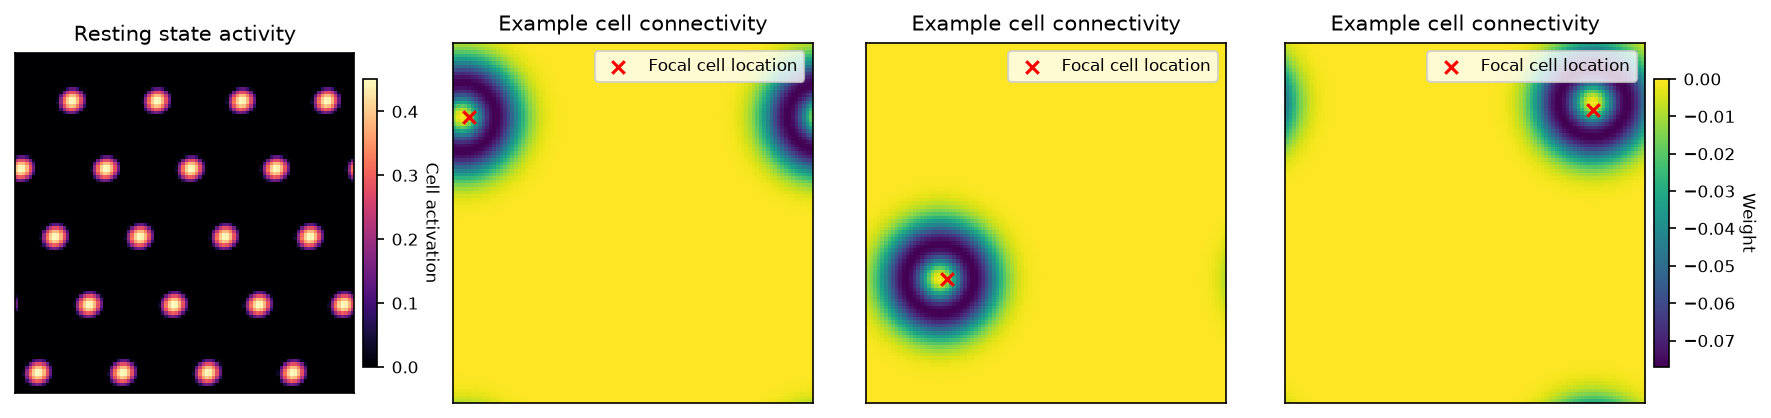

In [25]:
network_presentation(grid, show=False)
plt.savefig(FIG_PATH+"network_presentation.png", transparent=True)

### 2. Record pattern formation and dynamics

In [26]:
# uncomment to record pattern formation

"""
T = 0.02
dt = 1e-4
num_steps = int(T/dt)
v = np.zeros((num_steps, 2))
S = grid.simulate(v, s_0 = 0.001*np.random.randn(options.n**2)).squeeze()
plotting.plot_10_frames(S, dt)
plotting.rec_movie(S, fpath=FIG_PATH + 'pattern_formation.mp4', dt=dt, speed_ratio = 1/500)
"""

"\nT = 0.02\ndt = 1e-4\nnum_steps = int(T/dt)\nv = np.zeros((num_steps, 2))\nS = grid.simulate(v, s_0 = 0.001*np.random.randn(options.n**2)).squeeze()\nplotting.plot_10_frames(S, dt)\nplotting.rec_movie(S, fpath=FIG_PATH + 'pattern_formation.mp4', dt=dt, speed_ratio = 1/500)\n"

In [27]:
# uncomment to record pattern moving
'''
T = 0.5
dt = 1e-4
num_steps = int(T/dt)
v = np.zeros((num_steps, 2))
v[:num_steps//2, 0] = 1
v[num_steps//2:, 1] = 1

S = grid.simulate(v).squeeze()

labels = [rf'$v_x =${v[k, 0]}, $v_y=$ {v[k, 1]}' for k in range(len(v))]
plotting.rec_movie(S, fpath=FIG_PATH + 'pattern_moving.mp4', dt=dt, speed_ratio = 1/20, plot_blob_centers=True, frame_labels=labels)
'''

"\nT = 0.5\ndt = 1e-4\nnum_steps = int(T/dt)\nv = np.zeros((num_steps, 2))\nv[:num_steps//2, 0] = 1\nv[num_steps//2:, 1] = 1\n\nS = grid.simulate(v).squeeze()\n\nlabels = [rf'$v_x =${v[k, 0]}, $v_y=$ {v[k, 1]}' for k in range(len(v))]\nplotting.rec_movie(S, fpath=FIG_PATH + 'pattern_moving.mp4', dt=dt, speed_ratio = 1/20, plot_blob_centers=True, frame_labels=labels)\n"

### 3. Integrate random trajectory

In [28]:
# generate a trajectory 
box_width = box_height = 2.2 # m 
T = 10 # s
dt = grid.options.dt
seq_len = int(T/dt)

traj = generate_trajectory(box_width, box_height, seq_len, dt=dt, load=True, save=True, batch_size = 1, silent=False)
input_v = traj['input_v'].squeeze()
pos = np.stack([traj['target_x'].squeeze(), traj['target_y'].squeeze()], 1)

Found pre-computed trajectory at c:\Users\alexm\Documents\rise\a-bu-tism\grid_cells_burak_fiete-main/sim_data/trajectory_batchsize=1_len=20000_dt=0.0005_w=2.2_h=2.2_rotvelstd=1.6_meanv=0.8_border=0.03_borderslow=0.25.npy, loading it


In [29]:
def OU_increment(noise, tau, amp, dt):
    """
        Update OU process.
        speed_tau=2.0, dir_tau=1.0,

        :param float noise: current process value.
        :param float tau: relaxation time in seconds.
        :param float amp: scale of noise.
        :param float dt: time step length in seconds.
        :return update for OU process:
        :rtype float:
    """
    rng = np.random.default_rng()
    return -noise * dt / tau + rng.normal(loc=0.0, scale=amp * np.sqrt(dt))

In [30]:
#get input velocity, but it has OU noise
speed=traj["true_speed"][0]
head_dir=traj["true_hd"][0]
speed_noise = 0
dir_noise = 0
speed_tau = 2.0
dir_tau = 1.0
bio_speed_amp=0.05
bio_dir_amp=0.025
dt = 0.001
input_v = np.zeros((len(traj["true_speed"][0]),2))

for t in range(len(traj["true_speed"][0])):
    speed_noise += OU_increment(speed_noise, speed_tau, bio_speed_amp, dt)
    dir_noise += OU_increment(dir_noise, dir_tau, bio_dir_amp, dt)
    t_speed = max(0.0, speed[t] * (1 + speed_noise))
    t_headdir = head_dir[t] + dir_noise
    input_v[t] = np.array([t_speed * np.cos(t_headdir), t_speed*np.sin(t_headdir)])
print(input_v)


[[-0.60641528  0.5485845 ]
 [-1.41921021  1.26858887]
 [-0.33009367  0.28201072]
 ...
 [-0.99916106 -1.9509158 ]
 [-0.26513584 -0.47882608]
 [-1.09867916 -1.9195663 ]]


In [31]:
# Baseline

from grid_cells import Module
from phases_to_location import phasesToLocation1DProgressive

import numpy as np


class RunTrial:
    def __init__(self, NUM_OF_MODS=10, NUM_SPATIAL_PHASES=20, NUM_NEURONS_P_PHASE=20,
                 speed_noise_amplitude=0.05, headdir_noise_amplitude=0.025,
                 speed_tau=2.0, dir_tau=1.0,
                 ts=0.001, simlen=20000, deltahead=2.4,
                 spacing_min=25, scaling=1.65, bio_noise=False,
                 bio_speed_amp=0.05, bio_dir_amp=0.025, bio_speed_tau=2.0, bio_dir_tau=1.0,
                 speed=np.empty(0), head_dir=np.empty(0), og_position_x=np.empty(0), og_position_y=np.empty(0),
                 seed=67):
        self.NUM_MODULES = NUM_OF_MODS
        self.NUM_SPATIAL_PHASES = NUM_SPATIAL_PHASES
        self.NUM_NEURONS_P_PHASE = NUM_NEURONS_P_PHASE

        self.ts = ts  # in seconds, timestep
        self.simlen = simlen  # of timesteps, simulation length
        self.deltahead = deltahead  # in degrees

        self.speed = np.zeros(1)  # cm / s
        self.head_dir = np.zeros(1)  # radians
        self.final_og_position = np.zeros(2)  # cm

        '''
            documentation for below from grid_cells.py:

            speed_noise_amplitude: noise strength for fractional speed error. Default 0.05
            dir_noise_amplitude: noise strength for radian head direction error. Default 0.025
            speed_tau: relaxation constant for speed OU process. Default 2.0
            dir_tau: relaxation constant for head direction OU process. Default 1.0
        '''
        self.speed_noise_amplitude = speed_noise_amplitude
        self.dir_noise_amplitude = headdir_noise_amplitude
        self.speed_tau = speed_tau  # s
        self.dir_tau = dir_tau  # s

        self.bio_noise = bio_noise  # if there is biological noise (each module receives velocity w/ a different error)
        self.bio_speed_amp = bio_speed_amp
        self.bio_speed_tau = bio_speed_tau
        self.bio_dir_amp = bio_dir_amp
        self.bio_dir_tau = bio_dir_tau

        self.speed = speed
        self.head_dir = head_dir
        self.og_position_x = og_position_x
        self.og_position_y = og_position_y

        self.spacing_min = spacing_min  # cm, grid cell assembly
        self.scaling = scaling  # ratio, grid cell assembly

        self.seed = seed

        self.x_trig_dist = 0.0
        self.y_trig_dist = 0.0

        self.rng = np.random.default_rng(seed)

    def hex_basis_to_cart(self, u, v):
        x = u + 0.5 * v
        y = np.sqrt(3) / 2 * v
        return x, y

    def assembly_grid_cells(self):
        ''' generate grid cell structure of NUM_MODULES modules,
        each with 20 spatial phases, 20 neurons per phase'''
        self.s_is = [self.spacing_min * (self.scaling ** i) for i in range(self.NUM_MODULES)]
        self.modules = [Module(spacing=self.s_is[i],
                               bio_noise=self.bio_noise,
                               speed_tau=self.bio_speed_tau,
                               speed_amp=self.bio_speed_amp,
                               dir_tau=self.bio_dir_tau,
                               dir_amp=self.bio_dir_amp,
                               ) for i in range(self.NUM_MODULES)]

    def run_trial(self, error_freq: int = -1):
        """
        Simulates the grid cell phases changing by velocity of the mouse

        :param int error_freq:
            -1 if you just want to call get_location() at the end.
            otherwise frequency per time step that get_location()
            is called to determine time-based error.
            will call get_location() at end no matter what.
            e.g., 1 for calling get_location every timestep.
        """
        speed_noise = 0.0
        dir_noise = 0.0

        if (error_freq == -1):
            self.simulated_locations = np.zeros((1, 3))
        else:
            _len_for_sim_locations = int(np.floor(self.simlen / error_freq))
            if ((self.simlen - 1) % error_freq != 0): _len_for_sim_locations += 1
            self.simulated_locations = np.zeros((_len_for_sim_locations, 3))

        for t in range(self.simlen):
            # simulate velocity (with error).
            speed_noise += self.OU_increment(speed_noise, self.speed_tau, self.speed_noise_amplitude, self.ts)
            dir_noise += self.OU_increment(dir_noise, self.dir_tau, self.dir_noise_amplitude, self.ts)

            t_speed = max(0.0, self.speed[t] * (1 + speed_noise))
            t_headdir = self.head_dir[t] + dir_noise

            # update phase
            for i in range(self.NUM_MODULES):
                self.modules[i].update(t_speed, t_headdir, self.ts)

            # see current sim location & error
            if ((error_freq != -1 and t % error_freq == 0)):
                self.simulated_locations[int(t / error_freq)][0] = t
                self.simulated_locations[int(t / error_freq)][1:] = self.get_location()
            elif (t == self.simlen - 1):
                self.simulated_locations[-1][0] = t
                self.simulated_locations[-1][1:] = self.get_location()

        self.final_simulated_position = self.get_location()
        return self.simulated_locations[:,1:]

    def get_location(self):
        phases = np.array([self.modules[i].phase for i in range(self.NUM_MODULES)])
        data_x = np.zeros((self.NUM_MODULES, 2))
        data_x[:, 0] = self.s_is
        data_x[:, 1] = phases[:, 0]
        self.x_trig_dist = phasesToLocation1DProgressive(data_x, self.x_trig_dist)

        data_y = np.zeros((self.NUM_MODULES, 2))
        data_y[:, 0] = self.s_is
        data_y[:, 1] = phases[:, 1]
        self.y_trig_dist = phasesToLocation1DProgressive(data_y, self.y_trig_dist)
        return self.hex_basis_to_cart(self.x_trig_dist, self.y_trig_dist)

    def OU_increment(self, noise, tau, amp, dt):
        """
            Update OU process.

            :param float noise: current process value.
            :param float tau: relaxation time in seconds.
            :param float amp: scale of noise.
            :param float dt: time step length in seconds.
            :return update for OU process:
            :rtype float:
        """
        return -noise * dt / tau + self.rng.normal(loc=0.0, scale=amp * np.sqrt(dt))

trial = RunTrial(speed=traj["true_speed"][0], head_dir=traj["true_hd"][0],
                 og_position_x=traj["true_x"][0], og_position_y=traj["true_y"][0],
                 simlen=T*1000)

# pos_pred_baseline = np.zeros((10000, 2))
trial.assembly_grid_cells()
pos_pred_baseline = trial.run_trial(error_freq=1)


In [32]:
fname = f"example_sim_T={T}_dt={dt}_{grid.grid_id}.pth"
grid.save_sim = True
S = grid.simulate(input_v, sim_id = fname, silent=False, load=True) # set load = false to restart a new sim from scratch

# downsample if needed for faster analysis 
new_dt = 1E-3
S = utils.downsample(S, new_dt=new_dt, old_dt = dt, axis=1)
pos = utils.downsample(pos, new_dt=new_dt, old_dt = dt)

pos_pred_CAN, prop_factor, r2 = analysis.model_prediction(S, pos, verb = True)
pos_pred_CAN = np.vstack((pos[0], pos_pred_CAN))

Simulating with Euler method


  1%|▏         | 297/19999 [00:33<37:21,  8.79it/s]


KeyboardInterrupt: 

[[ 8.30262373e-04 -9.54879455e-05]
 [ 2.37211230e-03 -2.94662311e-04]
 [ 4.02785327e-03 -5.56175284e-04]
 ...
 [-5.94488641e-02  3.23582218e-01]
 [-5.94292315e-02  3.23927345e-01]
 [-5.93234213e-02  3.25684463e-01]]


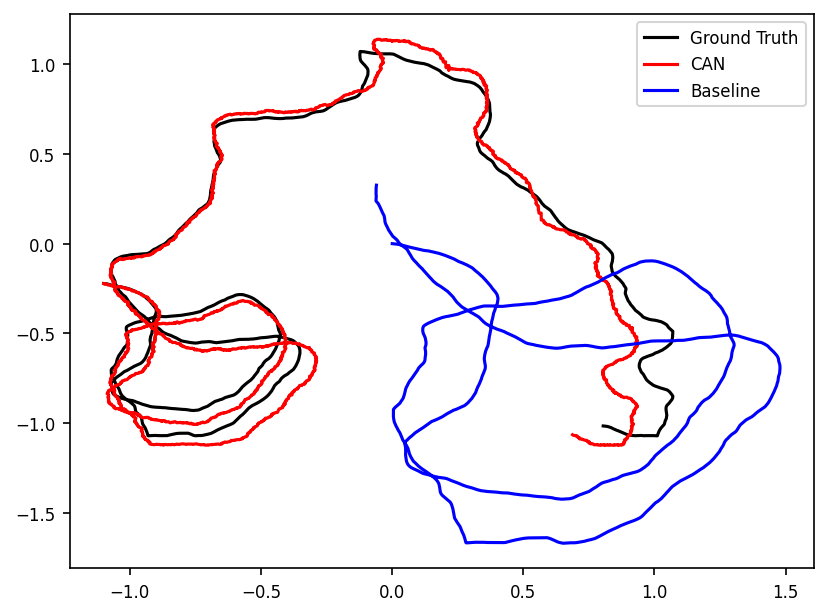

(20000, 2)
(20000, 2)
(10000, 2)


In [ ]:
# _ = plotting.compare_model_prediction(pos_pred_CAN, pos_pred_baseline, pos, box_width = box_width, box_height = box_height)
plotter = PathPlotter()

print(pos_pred_baseline)
pos_pred_baseline = pos_pred_baseline + traj

plotter.paths([pos, pos_pred_CAN, pos_pred_baseline], ["black", "red", "blue"], ["Ground Truth", "CAN", "Baseline"])
for arr in [pos, pos_pred_CAN, pos_pred_baseline]:
    print(arr.shape)

In [ ]:
import random


# module spacing trial..... do tmrw sophie

# parameter = `scaling`

#simulation time trial constants
trial_count_per_condition = 3
permutations = np.arange(1.4, 1.70001, 0.05)

error_freq = 1
speed_noise_amplitude =0.1
headdir_noise_amplitude = 0.05
ts = 0.001
sim_length_timesteps = 20_000
deltahead=2.4

seeds = [
    'sophie likes 67', 'grid cells are cool', 'schizophrenia', 'sarah', 'sophie is going crazy',
    'someone help her', 'her synaptic pruning is excessive', 'unlimited games', 'no games', 'unlimited bacon!'
][:7]
assert len(permutations) == len(seeds)

#running trials!
canless_sim_trial_rmses = np.zeros((len(permutations),trial_count_per_condition))
can_sim_trial_rmses = np.zeros((len(permutations),trial_count_per_condition))

speed_noise = 0
dir_noise = 0
speed_tau = 2.0
dir_tau = 1.0
bio_speed_amp=0.05
bio_dir_amp=0.025
dt = 0.001

for i in range(len(permutations)):
    for i in range(trial_count_per_condition):
        traj = generate_trajectory(box_width, box_height, seq_len, dt=dt, load=True, save=True, batch_size = 1, silent=False)
        ground_truth = np.array([traj['true_x'], traj['true_y']])
        speed = traj["true_speed"][0]
        head_dir =traj["true_hd"][0]

        # no can
        trial = RunTrial(speed=speed, head_dir=head_dir,
                 og_position_x=traj["true_x"][0], og_position_y=traj["true_y"][0],
                 simlen=T*2000)
        # pos_pred_baseline = np.zeros((10000, 2))
        trial.assembly_grid_cells()
        pos_pred_baseline = trial.run_trial(error_freq=1)
        rsme = np.sqrt(np.mean(np.sum((pos_pred_baseline-ground_truth.squeeze().T[2:])**2, axis=1)))
        canless_sim_trial_rmses[i] = rsme

        # can
        fname = f"example_sim_T={T}_dt={dt}_{grid.grid_id}.pth"
        grid.save_sim = True

        #get input velocity, but it has OU noise
        input_v = np.zeros((len(traj["true_speed"][0]),2))

        for t in range(len(traj["true_speed"][0])):
            speed_noise += OU_increment(speed_noise, speed_tau, bio_speed_amp, dt)
            dir_noise += OU_increment(dir_noise, dir_tau, bio_dir_amp, dt)
            t_speed = max(0.0, speed[t] * (1 + speed_noise))
            t_headdir = head_dir[t] + dir_noise
            input_v[t] = np.array([t_speed * np.cos(t_headdir), t_speed*np.sin(t_headdir)])

        S = grid.simulate(input_v, sim_id = fname, silent=False, load=True) # set load = false to restart a new sim from scratch
        # downsample if needed for faster analysis 
        new_dt = 1E-3
        S = utils.downsample(S, new_dt=new_dt, old_dt = dt, axis=1)
        pos = utils.downsample(pos, new_dt=new_dt, old_dt = dt)

        pos_pred_CAN, prop_factor, r2 = analysis.model_prediction(S, pos, verb = True)
        pos_pred_CAN = np.vstack((pos[0], pos_pred_CAN))

        rsme = np.sqrt(np.mean(np.sum((pos_pred_CAN-ground_truth.squeeze().T[2:])**2, axis=1)))
        can_sim_trial_rmses[i] = rsme


100%|██████████| 20001/20001 [00:01<00:00, 19197.46it/s]


Simulating with Euler method


 39%|███▊      | 7734/19999 [24:18<21:21,  9.57it/s]  

In [ ]:
x_labels = [f'{perm:.1f}' for perm in permutations]
x_pos = np.arange(len(x_labels))

canless_avg_rmses = np.mean(canless_sim_trial_rmses, axis=1)
can_sim_avg_rmses = np.mean(can_sim_trial_rmses, axis=1)

canless_std_rmses = np.std(canless_sim_trial_rmses, axis=1)
can_sim_std_rmses = np.std(can_sim_trial_rmses, axis=1)
width = 0.25

plt.figure(figsize=(12, 6))

xs = [x_pos - width/2, x_pos + width/2]

for x, rmse, std, label in zip(xs, [canless_avg_rmses, can_sim_avg_rmses], [canless_std_rmses, can_sim_std_rmses], ['No-CAN', 'CAN']):
    plt.bar(x, rmse, width, label=label, edgecolor='black', yerr=std, capsize=5, ecolor='DimGray')

plt.title(R"Effect of ${S_i}$ Growth Factor on No-CAN and CAN models")
plt.xlabel(R"${S_i}$ Growth Factor (unit-less)")
plt.ylabel("RMSE (cm)")
plt.xticks(x_pos, x_labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()